# 🏧 Loan Eligibility Prediction 💰 using Machine Learning Models 🤖

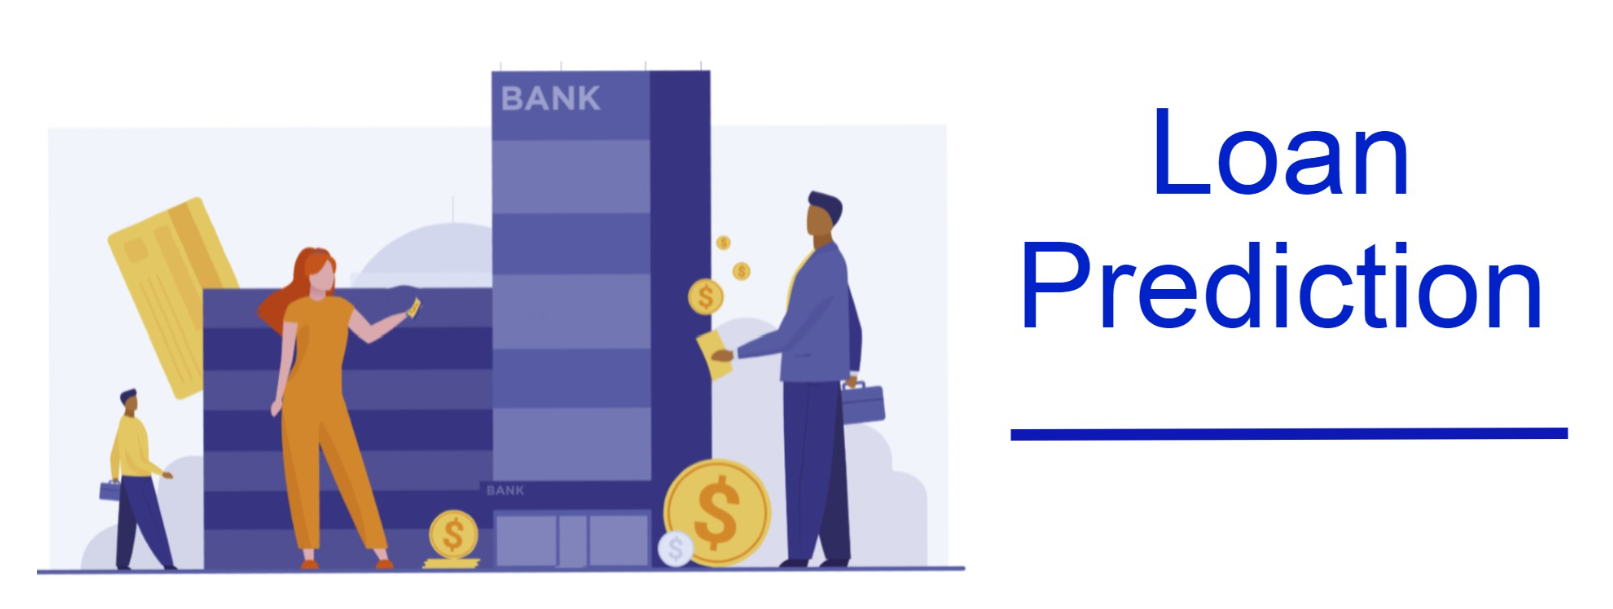

## In this notebook kernal, I'm going to predictions customers are eligible for the loan and check whether what are the missing criteria to know why customer not getting loan to make there own house.

#### The major aim of this notebook is to predict which of the customers will have their loan approved.


# Steps are :
##### Loading data  
##### Exploratory Data Analysis
##### Data Visualizations
##### Machine Learning Model Decision.
##### Traing the ML Model
##### Predict Model
##### Accuracy check

### Importing Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

### Importing & Loading the dataset

In [46]:
df_train = pd.read_csv('loan-train.csv')
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [47]:
df_train['Property_Area'].value_counts()

Semiurban    233
Urban        202
Rural        179
Name: Property_Area, dtype: int64

In [48]:
df_train['Loan_Status'].value_counts()

Y    422
N    192
Name: Loan_Status, dtype: int64

In [49]:
df_test= pd.read_csv('loan-test.csv')
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


##### Loan_ID--------------> Unique Loan ID.  
##### Gender --------------> Male/ Female
##### Married --------------> Applicant married (Y/N)
##### Dependents ------------> Number of dependents
##### Education -------------> Applicant Education (Graduate/ Under Graduate)
##### Self_Employed ---------> Self-employed (Y/N)
##### ApplicantIncome -------> Applicant income
##### CoapplicantIncome -----> Coapplicant income
##### LoanAmount -----------> Loan amount in thousands
##### Loan_Amount_Term ------> Term of a loan in months
##### Credit_History --------> Credit history meets guidelines
##### Property_Area ---------> Urban/ Semi-Urban/ Rural
##### Loan_Status -----------> Loan approved (Y/N)

## Dataset Info:

In [50]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Dataset Shape:

In [51]:
df_train.shape,df_test.shape

((614, 13), (367, 12))

In [52]:
df_train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## Data Cleaning

### Checking the Missing Values

In [53]:
df_train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### First we will fill the Missing Numerical column  by the 'Mean' & 'Mode' of the respective variables.

In [54]:
df_train['Credit_History'].fillna(df_train['Credit_History'].mode(),inplace=True ) 
df_test['Credit_History'].fillna(df_test['Credit_History'].mode(), inplace=True) 


df_train['LoanAmount'].fillna(df_train['LoanAmount'].mean(), inplace=True) 
df_test['LoanAmount'].fillna(df_test['LoanAmount'].mean(), inplace=True) 

### Converting Categorical variable with Numerical values.

Loan_Status feature boolean values, So we replace Y values with 1 and N values with 0 and same for other Boolean types of columns

In [55]:
df_train.Loan_Status = df_train.Loan_Status.replace({"Y": 1, "N" : 0})

df_train.Gender = df_train.Gender.replace({"Male": 1, "Female" : 0})
df_test.Gender = df_test.Gender.replace({"Male": 1, "Female" : 0})

df_train.Married = df_train.Married.replace({"Yes": 1, "No" : 0})
df_test.Married = df_test.Married.replace({"Yes": 1, "No" : 0})

df_train.Self_Employed = df_train.Self_Employed.replace({"Yes": 1, "No" : 0})
df_test.Self_Employed = df_test.Self_Employed.replace({"Yes": 1, "No" : 0})

### Now again converting all values with mode

In [56]:
df_train['Gender'].fillna(df_train['Gender'].mode()[0], inplace=True)
df_test['Gender'].fillna(df_test['Gender'].mode()[0], inplace=True)

df_train['Dependents'].fillna(df_train['Dependents'].mode()[0], inplace=True)
df_test['Dependents'].fillna(df_test['Dependents'].mode()[0], inplace=True)

df_train['Married'].fillna(df_train['Married'].mode()[0], inplace=True)
df_test['Married'].fillna(df_test['Married'].mode()[0], inplace=True)

df_train['Credit_History'].fillna(df_train['Credit_History'].mean(), inplace=True)
df_test['Credit_History'].fillna(df_test['Credit_History'].mean(), inplace=True)

df_train['Self_Employed'].fillna(df_train['Self_Employed'].mode()[0], inplace=True)
df_test['Self_Employed'].fillna(df_test['Self_Employed'].mode()[0], inplace=True)

df_train['Loan_Amount_Term'].fillna(df_train['Loan_Amount_Term'].mode()[0], inplace=True)
df_test['Loan_Amount_Term'].fillna(df_test['Loan_Amount_Term'].mode()[0], inplace=True)



In [57]:
df_train.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [58]:
df_test.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

#### Here, Property_Area, Dependents and Education has multiple values so now we can use LabelEncoder from sklearn package

In [59]:
from sklearn.preprocessing import LabelEncoder
feature_col = ['Property_Area','Education', 'Dependents']
le = LabelEncoder()
for col in feature_col:
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = le.fit_transform(df_test[col])

##### Here, we have dropped all the missing values to avoid disturbances in the model. The Loan Prediction requires all the details to work efficiently and thus the missing values are dropped.

### Now, Let's check the final Dataset Shape

In [60]:
df_train.shape,df_test.shape

((614, 13), (367, 12))

In [61]:
#created new column
df_train['Total_income'] = df_train['ApplicantIncome']+df_train['CoapplicantIncome']

In [62]:
cols = ['ApplicantIncome', 'CoapplicantIncome']
df = df_train.drop(columns=cols, axis=1,inplace=True)

In [63]:
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_income
0,LP001002,1.0,0.0,0,0,0.0,146.412162,360.0,1.0,2,1,5849.0
1,LP001003,1.0,1.0,1,0,0.0,128.000000,360.0,1.0,0,0,6091.0
2,LP001005,1.0,1.0,0,0,1.0,66.000000,360.0,1.0,2,1,3000.0
3,LP001006,1.0,1.0,0,1,0.0,120.000000,360.0,1.0,2,1,4941.0
4,LP001008,1.0,0.0,0,0,0.0,141.000000,360.0,1.0,2,1,6000.0


In [64]:
df_test['Total_income'] = df_test['ApplicantIncome']+df_test['CoapplicantIncome']
cols = ['ApplicantIncome', 'CoapplicantIncome']
df = df_test.drop(columns=cols, axis=1,inplace=True)

In [65]:
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_income
0,LP001015,1.0,1,0,0,0.0,110.0,360.0,1.000000,2,5720
1,LP001022,1.0,1,1,0,0.0,126.0,360.0,1.000000,2,4576
2,LP001031,1.0,1,2,0,0.0,208.0,360.0,1.000000,2,6800
3,LP001035,1.0,1,2,0,0.0,100.0,360.0,0.825444,2,4886
4,LP001051,1.0,0,0,1,0.0,78.0,360.0,1.000000,2,3276


### Data Visualizations

<AxesSubplot:>

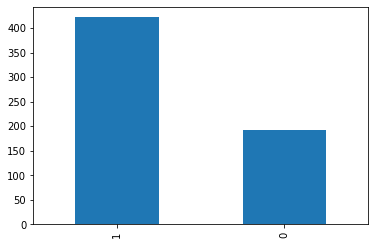

In [22]:
df_train['Loan_Status'].value_counts().plot.bar()

<AxesSubplot:xlabel='LoanAmount', ylabel='Density'>

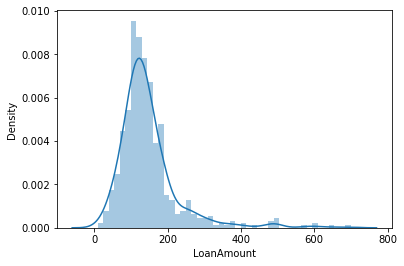

In [23]:
sns.distplot(df_train.LoanAmount)

<AxesSubplot:xlabel='Credit_History', ylabel='Density'>

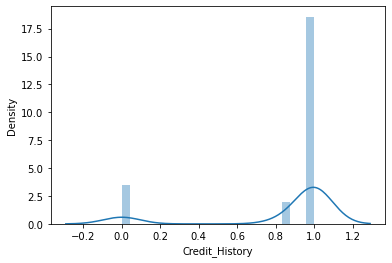

In [24]:
sns.distplot(df_train.Credit_History)

<AxesSubplot:xlabel='Total_income', ylabel='Density'>

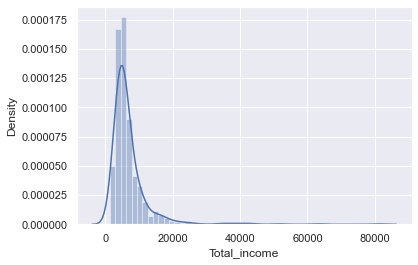

In [140]:
sns.distplot(df_train.Total_income)

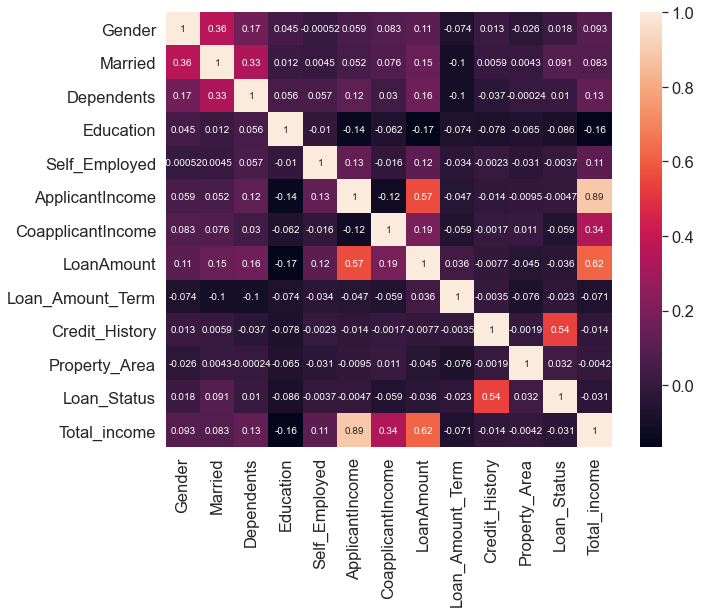

In [106]:
plt.figure(figsize=(10,8))
sns.heatmap(df_train.corr(),annot=True)
sns.set_theme(font_scale=1)

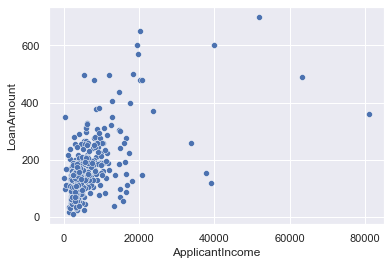

In [18]:
sns.scatterplot('ApplicantIncome','LoanAmount',data=df_train)
sns.set_theme(font_scale=1.5)

#### Here we can observe that Loan Amount and Applicant Income is highly related

### Comparison between Parameters in getting the Loan:

<AxesSubplot:xlabel='Property_Area', ylabel='count'>

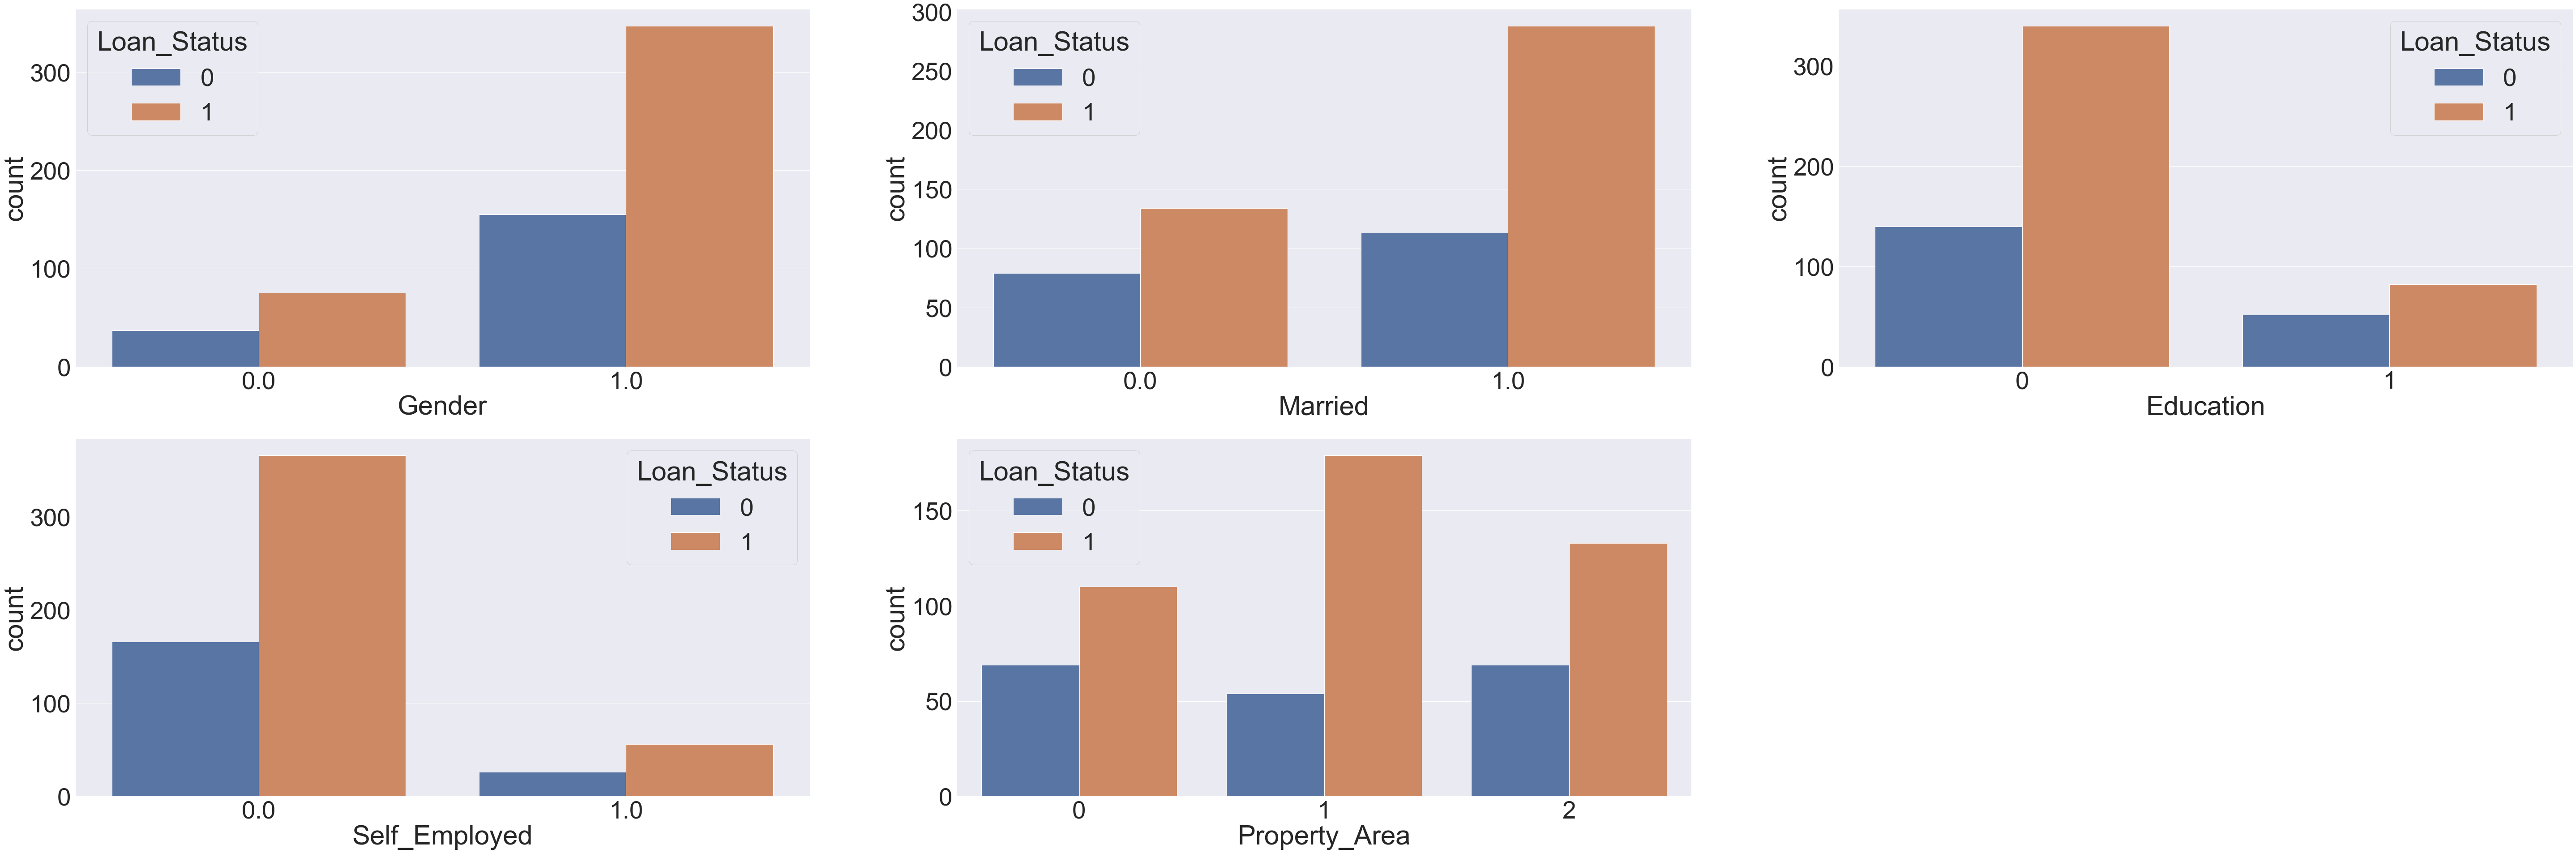

In [141]:
plt.figure(figsize = (100, 50))
sns.set(font_scale = 5)
plt.subplot(331)
sns.countplot(df_train['Gender'],hue=df_train['Loan_Status'])

plt.subplot(332)
sns.countplot(df_train['Married'],hue=df_train['Loan_Status'])

plt.subplot(333)
sns.countplot(df_train['Education'],hue=df_train['Loan_Status'])

plt.subplot(334)
sns.countplot(df_train['Self_Employed'],hue=df_train['Loan_Status'])

plt.subplot(335)
sns.countplot(df_train['Property_Area'],hue=df_train['Loan_Status'])



In [ ]:
df_train.head()

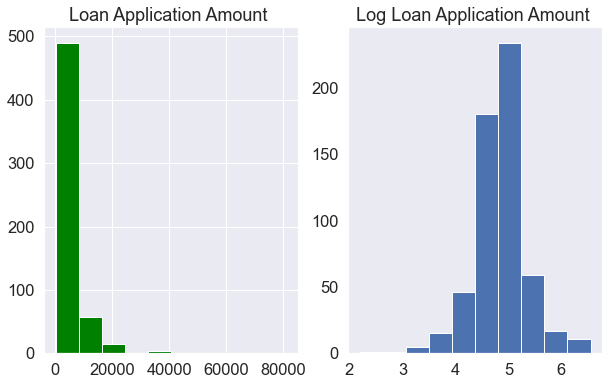

In [142]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)


df_train['ApplicantIncome'].hist(bins=10,color='green')
plt.title("Loan Application Amount ")

plt.subplot(1, 2, 2)
plt.grid()
plt.hist(np.log(df_train['LoanAmount']))
plt.title("Log Loan Application Amount ")
sns.set_theme(font_scale=1.5)
plt.show()

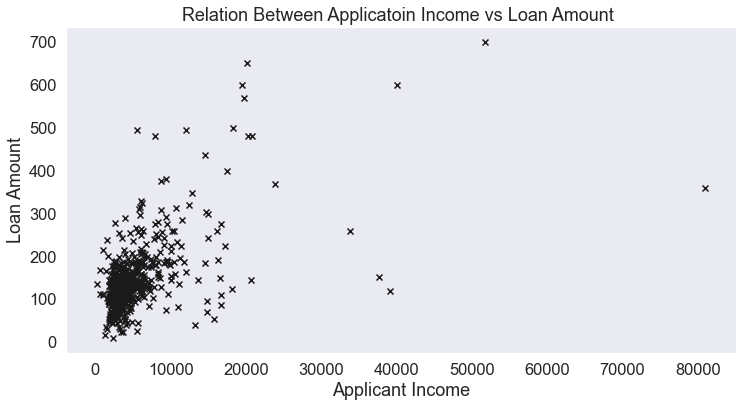

In [232]:
plt.figure(figsize=(12, 6))
plt.title("Relation Between Applicatoin Income vs Loan Amount ")

plt.grid()
plt.scatter(df_train['ApplicantIncome'] , df_train['LoanAmount'], c='k', marker='x')
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

In [66]:
df_train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_income
0,LP001002,1.0,0.0,0,0,0.0,146.412162,360.0,1.0,2,1,5849.0
1,LP001003,1.0,1.0,1,0,0.0,128.000000,360.0,1.0,0,0,6091.0
2,LP001005,1.0,1.0,0,0,1.0,66.000000,360.0,1.0,2,1,3000.0
3,LP001006,1.0,1.0,0,1,0.0,120.000000,360.0,1.0,2,1,4941.0
4,LP001008,1.0,0.0,0,0,0.0,141.000000,360.0,1.0,2,1,6000.0


In [67]:
df_test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_income
0,LP001015,1.0,1,0,0,0.0,110.0,360.0,1.000000,2,5720
1,LP001022,1.0,1,1,0,0.0,126.0,360.0,1.000000,2,4576
2,LP001031,1.0,1,2,0,0.0,208.0,360.0,1.000000,2,6800
3,LP001035,1.0,1,2,0,0.0,100.0,360.0,0.825444,2,4886
4,LP001051,1.0,0,0,1,0.0,78.0,360.0,1.000000,2,3276


## Now from here we will apply our models

In [68]:
features=['Gender','Married','Dependents','Education','Self_Employed','LoanAmount','Loan_Amount_Term','Credit_History','Property_Area','Property_Area']

In [69]:
x_train = df_train[features].values
y_train = df_train['Loan_Status'].values

x_test = df_test[features].values

# Model Building

#### Logistic Regression

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [84]:
lr=LogisticRegression()

In [86]:
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
lr.score(x_train, y_train)
lr= round(lr.score(x_train, y_train) * 100, 2)
lr

80.94

##### Accuracy Score is 80.94%

In [37]:
dff = pd.DataFrame({"Loan_ID": df_test["Loan_ID"], "Loan_Status": y_pred})
dff[0:10]

,Loan_ID,Loan_Status
0,LP001015,1
1,LP001022,1
2,LP001031,1
3,LP001035,1
4,LP001051,1
5,LP001054,1
6,LP001055,1
7,LP001056,0
8,LP001059,1
9,LP001067,1


In [38]:
dff["Loan_Status"].value_counts()

1    308
0     59
Name: Loan_Status, dtype: int64

In [ ]:
dff.to_csv('Final_loan_data.csv', index=False)
print("Your submission was successfully saved!")

### Decision Tree

In [347]:
x_train = df_train[train_features].values
y_train = df_train['Loan_Status'].values

x_test = df_test[train_features].values

In [348]:
from sklearn.tree import DecisionTreeClassifier

In [349]:
dtr=DecisionTreeClassifier()

In [350]:
dtr.fit(x_train,y_train)

DecisionTreeClassifier()

In [351]:
y_pred=dtr.predict(x_test)

In [352]:
from sklearn.metrics import accuracy_score
dtr.score(x_train, y_train)
dtr= round(dtr.score(x_train, y_train) * 100, 2)
dtr

80.94

### Random Forest

In [323]:
x_train = df_train[train_features].values
y_train = df_train['Loan_Status'].values

x_test = df_test[train_features].values

In [324]:
from sklearn.ensemble import RandomForestClassifier

In [325]:
rfc= RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)

In [326]:
rfc.fit(x_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [327]:
y_pred=rfc.predict(x_test)

In [328]:
from sklearn.metrics import accuracy_score
rfc.score(x_train, y_train)
rfc= round(rfc.score(x_train, y_train) * 100, 2)
rfc

80.94

### CONCLUSION:

#### The Loan Status is heavily dependent on the Credit History for Predictions.
#### The Logistic Regression algorithm gives us the maximum Accuracy (81% approx) compared to the other 3 Machine Learning Classification Algorithms.
 